# revisiting_threeNucl_mappy.ipynb
## Marcus Viscardi,    June 29, 2023

So it sounds like we are hitting a wall with getting minimap2 to align the cDNA libraries from TAD treated libraries (specifically w/ 3nt genomes?).

Some of the libraries (best ones):
` /data16/marcus/working/230613_nanoporeRun_sMV025-RNAStds_50-50_LT_TAD_Nano3P `
` /data16/marcus/working/230612_nanoporeRun_sMV025-RNAStds_50-50_LT_MockTAD_Nano3P `

In [4]:
import mappy
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from Bio import SeqIO, Seq, SeqRecord
import pysam
import seaborn as sns
import nanoporePipelineCommon as npC

print(f"Imports done at {npC.get_dt(for_print=True)}")

Imports done at 07/10/23 @ 12:28:39 PM


# Paths:

In [5]:
# Libraries
treated_parent = Path('/data16/marcus/working/230613_nanoporeRun_sMV025-RNAStds_50-50_LT_TAD_Nano3P/output_dir')
mock_parent = Path('/data16/marcus/working/230612_nanoporeRun_sMV025-RNAStds_50-50_LT_MockTAD_Nano3P/output_dir')

treated_fastq = treated_parent / 'cat_files' / 'cat.fastq'
mock_fastq = mock_parent / 'cat_files' / 'cat.fastq'

treated_bam = treated_parent / 'cat_files' / 'cat.sorted.mappedAndPrimary.bam'
mock_bam = mock_parent / 'cat_files' / 'cat.sorted.mappedAndPrimary.bam'

# Genome
genome_parent = Path('/data16/liam/genomes/plus_cerENO2_elegansRelease100')
genome_cDNA_fasta = genome_parent / '230327_allcDNA_plus-cerENO2.cdna.all.fa'
genome_DNA_fasta = genome_parent / '230327_allChrs_plus-cerENO2.allChrs.fa'
genome_gtf = genome_parent / '230327_allChrs_plus-cerENO2.gtf'
genome_parsed_gtf = genome_parent / '230327_allChrs_plus-cerENO2.gtf.parquet'
genome_bed = genome_parent / '230327_allChrs_plus-cerENO2.bed'

# Outputs
fastx_files = Path('/data16/liam/scripts/nanoporePipelineScripts/mappyWithExtendedNuclCode/fastxFiles')
genome_files = Path('/data16/liam/scripts/nanoporePipelineScripts/mappyWithExtendedNuclCode/genomeFiles')

# Make 3NT reads:

Going to just run with ChrIII because it is the shortest chromosome (@ 13,783,801bp)

I'll also use the BAM file to just keep reads that had an alignment to the genome on ChrIII, so we don't have to trudge through all the reads for testing.
***
**@Liam:** You can probably skip this cell and the next. Didn't take very long to run, but the outputs are already made. Feel free to edit and run if you want to mess with it thou.

In [6]:

target_bam = treated_bam
lib_name = target_bam.parent.parent.parent.stem
target_chr = 'III'

# Read BAM and hold onto any reads that had previous hit the target_chr (ChrIII)
output_rec_list = []
for read in pysam.Samfile(target_bam, 'rb').fetch(target_chr):
    seq = Seq.Seq(read.seq)
    rec = SeqRecord.SeqRecord(seq, id=read.qname, description='')
    output_rec_list.append(rec)
# Save to a fasta file
SeqIO.write(output_rec_list, fastx_files / f'{lib_name}_Chr{target_chr}-Hits.4nucl.fasta', 'fasta')
print(len(output_rec_list))

# Now make the modified versions:
mod_GtoT_rec_list = []
mod_CtoA_rec_list = []
mod_GtoA_rec_list = []
mod_AtoG_rec_list = []

for rec in output_rec_list:
    GtoT = str(rec.seq).replace('G', 'T')
    AtoG = str(rec.seq).replace('A', 'G')
    GtoA = str(rec.seq).replace('G', 'A') # This one doesn't really make sense... but might as well be thorough
    CtoA = str(rec.seq).replace('C', 'A')  # This one doesn't really make sense... but might as well be thorough
    mod_AtoG_rec_list.append(SeqRecord.SeqRecord(Seq.Seq(AtoG), id=rec.id, description=''))
    mod_GtoA_rec_list.append(SeqRecord.SeqRecord(Seq.Seq(GtoA), id=rec.id, description=''))
    mod_GtoT_rec_list.append(SeqRecord.SeqRecord(Seq.Seq(GtoT), id=rec.id, description=''))
    mod_CtoA_rec_list.append(SeqRecord.SeqRecord(Seq.Seq(CtoA), id=rec.id, description=''))

# Save to a fasta file
SeqIO.write(mod_AtoG_rec_list, fastx_files / f'{lib_name}_Chr{target_chr}-Hits.3nucl.AtoG.fasta', 'fasta')
SeqIO.write(mod_GtoA_rec_list, fastx_files / f'{lib_name}_Chr{target_chr}-Hits.3nucl.GtoA.fasta', 'fasta')
SeqIO.write(mod_GtoT_rec_list, fastx_files / f'{lib_name}_Chr{target_chr}-Hits.3nucl.GtoT.fasta', 'fasta')
SeqIO.write(mod_CtoA_rec_list, fastx_files / f'{lib_name}_Chr{target_chr}-Hits.3nucl.CtoA.fasta', 'fasta')

390


390

# Create the modified "genomes"
(These "genomes" are just ChrIII)

In [7]:
# Edit the genome to only include ChrIII and make modified versions:
# First lets just save a copy of ChrIII and a rev_comp version in our working dir
genome = SeqIO.to_dict(SeqIO.parse(genome_DNA_fasta, 'fasta'))
chrIII = genome['III']
SeqIO.write([chrIII], genome_files / 'III.4nucl.fa', 'fasta')
chrIII_rev_comp = chrIII.reverse_complement()
chrIII_rev_comp.id = chrIII.id + '.rev_comp'
chrIII_rev_comp.description = ' '.join(chrIII_rev_comp.description.split(' ')[1:])
SeqIO.write([chrIII_rev_comp], genome_files / 'III.4nucl.rev_comp.fa', 'fasta')

# Now lets make the modified versions:
# A to G
chrIII_3nucl_AtoG = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('A', 'G')),
                                        id=chrIII.id + '.AtoG',
                                        description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_AtoG], genome_files / 'III.3nucl.AtoG.fa', 'fasta')

# A to G rev_comp
chrIII_3nucl_AtoG_rev_comp = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('A', 'G')).reverse_complement(),
                                                 id=chrIII.id + '.AtoG',
                                                 description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_AtoG_rev_comp], genome_files / 'III.3nucl.AtoG.rev_comp.fa', 'fasta')
# G to T
chrIII_3nucl_GtoT = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('G', 'T')),
                                        id=chrIII.id + '.GtoT',
                                        description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_GtoT], genome_files / 'III.3nucl.GtoT.fa', 'fasta')

# G to T rev_comp
chrIII_3nucl_GtoT_rev_comp = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('G', 'T')).reverse_complement(),
                                                 id=chrIII.id + '.GtoT',
                                                 description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_GtoT_rev_comp], genome_files / 'III.3nucl.GtoT.rev_comp.fa', 'fasta')

# G to A
chrIII_3nucl_GtoA = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('G', 'A')),
                                        id=chrIII.id + '.GtoA',
                                        description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_GtoA], genome_files / 'III.3nucl.GtoA.fa', 'fasta')

# G to A rev_comp
chrIII_3nucl_GtoA_rev_comp = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('G', 'A')).reverse_complement(),
                                                 id=chrIII.id + '.GtoA',
                                                 description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_GtoA_rev_comp], genome_files / 'III.3nucl.GtoA.rev_comp.fa', 'fasta')

# C to A
chrIII_3nucl_CtoA = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('C', 'A')),
                                        id=chrIII.id + '.CtoA',
                                        description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_CtoA], genome_files / 'III.3nucl.CtoA.fa', 'fasta')

# C to A rev_comp
chrIII_3nucl_CtoA_rev_comp = SeqRecord.SeqRecord(Seq.Seq(str(chrIII.seq).replace('C', 'A')).reverse_complement(),
                                                 id=chrIII.id + '.CtoA',
                                                 description=' '.join(chrIII.description.split(' ')[1:]))
SeqIO.write([chrIII_3nucl_CtoA_rev_comp], genome_files / 'III.3nucl.CtoA.rev_comp.fa', 'fasta')

1

# Build the mappy aligners
We can make one for each modified and reverse complimented genome

[Link to SUPER SHORT Mappy documentation](https://pypi.org/project/mappy/)

In [6]:
mappy_aligner_dict = {}
for genome_path in genome_files.iterdir():
    if genome_path.suffix == '.fa':
        mappy_aligner_dict[genome_path.stem] = mappy.Aligner(str(genome_path),
                                                             preset='map-ont',  # avoiding using the splice options for now
                                                             best_n=1,  # only keeps one hit (no secondary's)
                                                             n_threads=16,
                                                             extra_flags=0x100000,
                                                            #  #           0x100000 = FWD alignments only
                                                            #  #           0x200000 = REV alignments only
                                                             )

# Start aligning!?
***
**@Liam**: This is probably where you can dig in a bit with some diagnostics

In [14]:
target_fasta = fastx_files / f'{lib_name}_Chr{target_chr}-Hits.3nucl.AtoG.fasta'
                        #    f'{lib_name}_Chr{target_chr}-Hits.3nucl.GtoT.fasta'
#                            f'{lib_name}_Chr{target_chr}-Hits.3nucl.CtoA.fasta'
print(len(target_fasta.read_text().split('>')) - 1)

mapq_scores = []
read_lengths = []
gc = []
hit_count = 0
for read in SeqIO.parse(target_fasta, 'fasta'):
    print(read.id)
    for genome_name, aligner in mappy_aligner_dict.items():
        for hit in aligner.map(str(read.seq), cs=True, MD=True):
            mapq_scores.append(hit.mapq)
            read_lengths.append(len(str(read.seq)))
            gc.append((str(read.seq).count('G') + str(read.seq).count('C'))/len(str(read.seq)))
            print(f"{genome_name:<30}{hit}")  # TODO: A bit more here would allow for a lot of diagnostics! Good for Liam.
            hit_count += 1
    print()

print(f'Hit count: {hit_count}')

390
5756fbbe-b929-437c-a0d9-e91f3f2c79e5
III.3nucl.AtoG                0	316	+	III.AtoG	13783801	41697	42020	293	327	60	tp:A:P	ts:A:.	cg:Z:23M1I10M4D87M2I12M1I36M3D65M4D79M	cs:Z::4*ct:18+c:5*gc:1*gc:2-ggct:87+gt:2*ct*gt:8+g:36-gcc:6*tc:54*gc:1*gc:1-gtgc:34*gt*gt*gt:5*gt*gt*gt*ct*gt:1*gt*gt:19*tc:9

c9ab481d-b1ef-49f8-b518-ab457b05b889
III.3nucl.AtoG                149	580	+	III.AtoG	13783801	253265	253716	392	466	60	tp:A:P	ts:A:.	cg:Z:7M1D21M1I5M2D15M1D2M1D14M1I8M2D40M2I5M3D9M3D10M1I8M1I16M2D18M1D14M2I4M2I10M1D13M2I22M3D20M1I10M4D4M3D21M1I1M1I10M1D66M2D14M4D15M1D14M	cs:Z::7-t:21+c:5-cg:1*tc:13-g:2-g:7*tc*ct:5+g:8-tt:1*tg:1*cg:1*gt*cg:1*ct:15*ct:15+cc*tg*tc:3-gcc:9-ctt:10+t:8+t:2*tc:13-tt:18-t:14+tt:4+tt:10-t*tc:2*tg:9+tt:12*ct*tc:4*tc:3-ccc:7*ct:2*ct*ct:8+c*tc:9-ggtt*gc:3-gtc:21+c:1+g:3*cg:4*tc:1-g:66-gt:14-ggtt:15-t:14
III.3nucl.AtoG                1	169	+	III.AtoG	13783801	251774	251937	154	170	60	tp:A:P	ts:A:.	cg:Z:6M3I3M1D55M1I65M2I9M1D10M1I13M	cs:Z::6+tct:3-t:4*ct:50+t:4*gt:60+tt:

<AxesSubplot: ylabel='Density'>

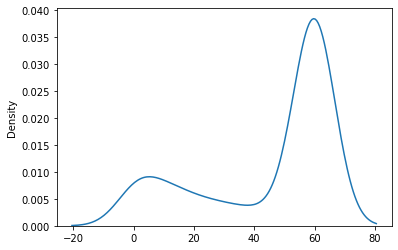

In [8]:
import seaborn as sns

sns.kdeplot(mapq_scores)

<AxesSubplot: ylabel='Count'>

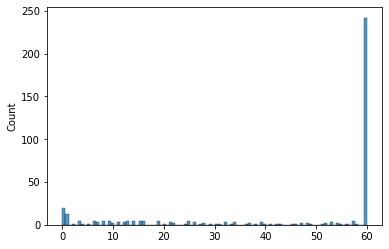

In [9]:
sns.histplot(mapq_scores, bins=100)

<AxesSubplot: ylabel='Density'>

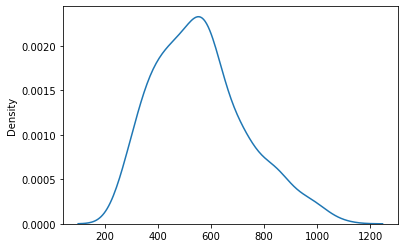

In [11]:
sns.kdeplot(read_lengths)

In [1]:
sns.kdeplot(gc,legend=False)

NameError: name 'sns' is not defined

# Parsing Cigar Strings

In [ ]:
target_fasta = fastx_files / f'{lib_name}_Chr{target_chr}-Hits.3nucl.AtoG.fasta'
                        #    f'{lib_name}_Chr{target_chr}-Hits.3nucl.GtoT.fasta'
#                            f'{lib_name}_Chr{target_chr}-Hits.3nucl.CtoA.fasta'
print(len(target_fasta.read_text().split('>')) - 1)

mapq_scores = []
read_lengths = []
gc = []
hit_count = 0
for read in SeqIO.parse(target_fasta, 'fasta'):
    print(read.id)
    for genome_name, aligner in mappy_aligner_dict.items():
        for hit in aligner.map(str(read.seq), cs=True, MD=True):
            mapq_scores.append(hit.mapq)
            read_lengths.append(len(str(read.seq)))
            gc.append((str(read.seq).count('G') + str(read.seq).count('C'))/len(str(read.seq)))
            print(f"{genome_name:<30}{hit}")  # TODO: A bit more here would allow for a lot of diagnostics! Good for Liam.
            hit_count += 1
    print()

print(f'Hit count: {hit_count}')